In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import sys

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

BASE_DIR = Path("../")

data = pd.read_csv(BASE_DIR/"data/raw/data.csv")

features = pd.read_csv(BASE_DIR/"data/raw/features.csv")

stores = pd.read_csv(BASE_DIR/"data/raw/stores.csv")

In [2]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [3]:
data.tail()

,Store,Dept,Date,Weekly_Sales,IsHoliday
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False
421569,45,98,2012-10-26,1076.80,False


In [4]:
data.shape

(421570, 5)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [6]:
data.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [7]:
data["Date"] = pd.to_datetime(data["Date"])
data.dtypes

Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object

In [56]:
data["Date"].max()

Timestamp('2012-10-26 00:00:00')

In [8]:
data.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.nunique()

Store               45
Dept                81
Date               143
Weekly_Sales    359464
IsHoliday            2
dtype: int64

In [11]:
data["Weekly_Sales"].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

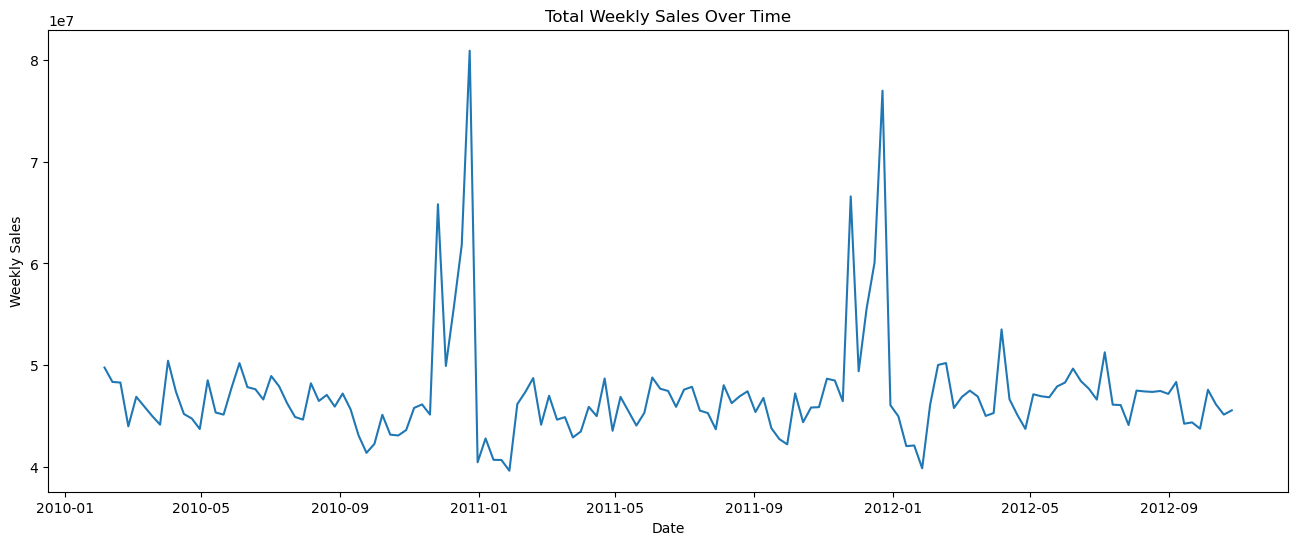

In [12]:
sales = data.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(16,6))
plt.plot(sales.index, sales.values)
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(sales.values)

print("ADF Statistic :", result[0])
print("p-value       :", result[1])
print("Lags Used     :", result[2])
print("Observations  :", result[3])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")
# ADF Stat < Critical Values 

if result[1] <= 0.05:
    print("The time series is Stationary.")
else:
    print("The time series is Non-Stationary.")

ADF Statistic : -5.908297957186333
p-value       : 2.675979158986027e-07
Lags Used     : 4
Observations  : 138

Critical Values:
1%: -3.47864788917503
5%: -2.882721765644168
10%: -2.578065326612056
The time series is Stationary.


In [14]:
from statsmodels.tsa.stattools import kpss

result = kpss(sales.values, regression="c", nlags="auto")

print("KPSS Statistic :", result[0])
print("p-value        :", result[1])
print("Lags Used      :", result[2])

print("\nCritical Values:")
for key, value in result[3].items():
    print(f"{key}: {value}")

if result[1] > 0.05:
    print("\nThe time series is Stationary.")
else:
    print("\nThe time series is Non-Stationary.")

KPSS Statistic : 0.04889162911078007
p-value        : 0.1
Lags Used      : 5

Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739

The time series is Stationary.


C:\Users\Swaraj Shedge\AppData\Local\Temp\ipykernel_10984\3570939261.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(sales.values, regression="c", nlags="auto")


In [15]:
from statsmodels.stats.diagnostic import acorr_ljungbox

result = acorr_ljungbox(sales, lags=[10], return_df=True)

print(result)

if result["lb_pvalue"].iloc[0] > 0.05:
    print("No significant autocorrelation.")
else:
    print("Significant autocorrelation exists.")

      lb_stat     lb_pvalue
10  47.167774  8.801796e-07
Significant autocorrelation exists.


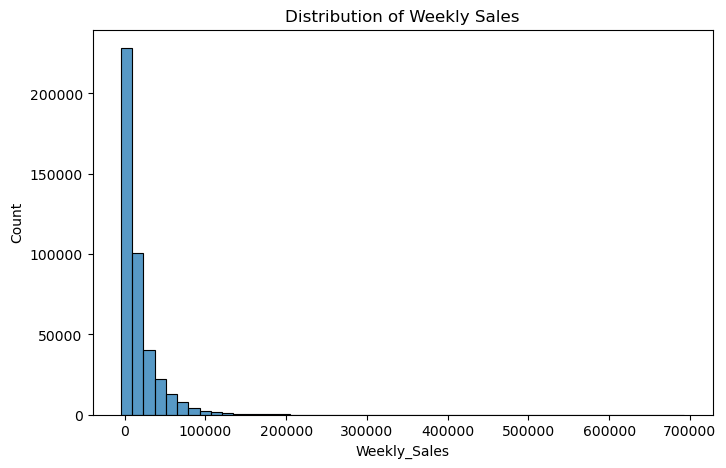

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data["Weekly_Sales"], bins=50)
plt.title("Distribution of Weekly Sales")
plt.show()

In [18]:
data[data["Weekly_Sales"]>600000]

,Store,Dept,Date,Weekly_Sales,IsHoliday
95373,10,72,2010-11-26,693099.36,True
95425,10,72,2011-11-25,630999.19,True
337961,35,72,2010-11-26,627962.93,True
338013,35,72,2011-11-25,649770.18,True


In [19]:
data[data["Weekly_Sales"]<0]

,Store,Dept,Date,Weekly_Sales,IsHoliday
846,1,6,2012-08-10,-139.65,False
2384,1,18,2012-05-04,-1.27,False
6048,1,47,2010-02-19,-863.00,False
6049,1,47,2010-03-12,-698.00,False
6051,1,47,2010-10-08,-58.00,False
...,...,...,...,...,...
419597,45,80,2010-02-12,-0.43,True
419598,45,80,2010-02-19,-0.27,False
419603,45,80,2010-04-16,-1.61,False
419614,45,80,2010-07-02,-0.27,False


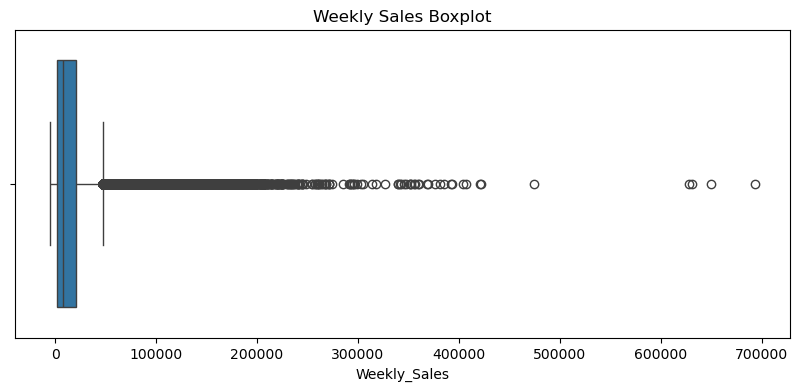

In [20]:
plt.figure(figsize=(10,4))
sns.boxplot(x=data["Weekly_Sales"])
plt.title("Weekly Sales Boxplot")
plt.show()

In [21]:
data.groupby("IsHoliday")["Weekly_Sales"].mean()

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

In [22]:
data["Store"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

In [23]:
data.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False)

Store
20    29508.301592
4     29161.210415
14    28784.851727
13    27355.136891
2     26898.070031
10    26332.303819
27    24826.984536
6     21913.243624
1     21710.543621
39    21000.763562
19    20362.126734
23    19776.180881
31    19681.907464
11    19276.762751
24    18969.106500
28    18714.889803
41    17976.004648
32    16351.621855
18    15733.313136
22    15181.218886
12    14867.308619
26    14554.129672
35    13803.596986
40    13763.632803
34    13522.081671
43    13415.114118
8     13133.014768
17    12954.393636
45    11662.897315
42    11443.370118
21    11283.435496
25    10308.157810
37    10297.355026
15     9002.493073
9      8772.890379
30     8764.237719
36     8584.412563
7      8358.766148
29     8158.810609
16     7863.224124
38     7492.478460
3      6373.033983
44     6038.929814
33     5728.414053
5      5053.415813
Name: Weekly_Sales, dtype: float64

In [24]:
data["Dept"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 40, 41, 42, 44, 45, 46, 47, 48, 49, 51, 52, 54, 55, 56,
       58, 59, 60, 67, 71, 72, 74, 77, 78, 79, 80, 81, 82, 83, 85, 87, 90,
       91, 92, 93, 94, 95, 96, 97, 98, 99, 39, 50, 43, 65])

In [25]:
data.groupby("Dept")["Weekly_Sales"].mean().sort_values(ascending=False)

Dept
92    75204.870531
95    69824.423080
38    61090.619568
72    50566.515417
65    45441.706224
          ...     
51       21.931729
39       11.123750
78        7.296638
43        1.193333
47       -7.682554
Name: Weekly_Sales, Length: 81, dtype: float64

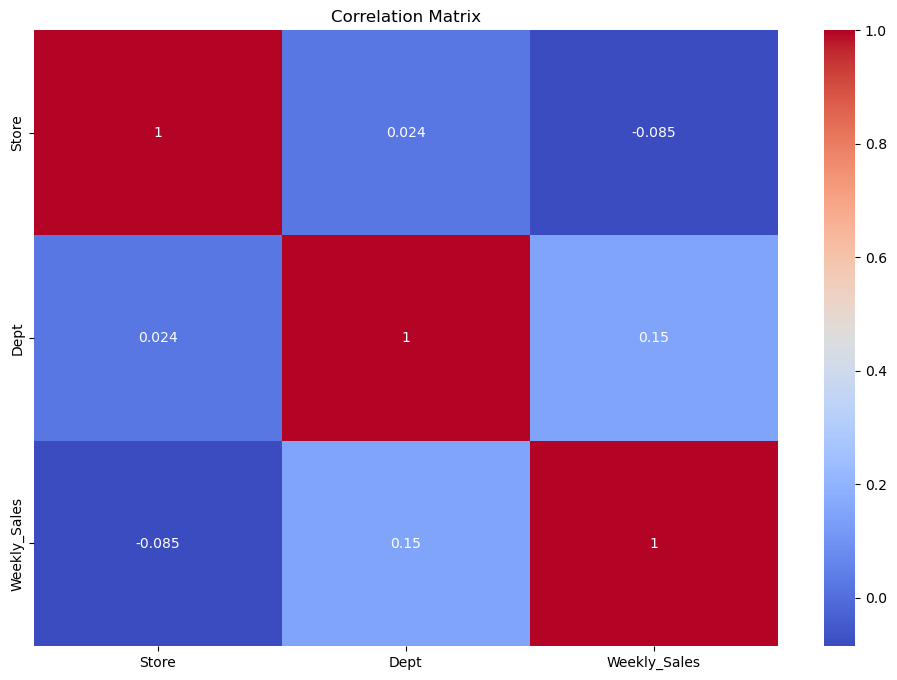

In [26]:
numeric_df = data.select_dtypes(include="number")

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [27]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [28]:
data['IsHoliday'].value_counts()

IsHoliday
False    391909
True      29661
Name: count, dtype: int64

# Data cleaning and Preprocessing

In [29]:
# Create a copy of the original dataframe
cleaned_data = data.copy()

In [30]:
cleaned_data["IsHoliday"] = cleaned_data["IsHoliday"].astype(int)

In [31]:
cleaned_data["Year"] = cleaned_data["Date"].dt.year
cleaned_data["Month"] = cleaned_data["Date"].dt.month
cleaned_data["Week"] = cleaned_data["Date"].dt.isocalendar().week.astype(int)

In [32]:
cleaned_data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week
0,1,1,2010-02-05,24924.50,0,2010,2,5
1,1,1,2010-02-12,46039.49,1,2010,2,6
2,1,1,2010-02-19,41595.55,0,2010,2,7
3,1,1,2010-02-26,19403.54,0,2010,2,8
4,1,1,2010-03-05,21827.90,0,2010,3,9


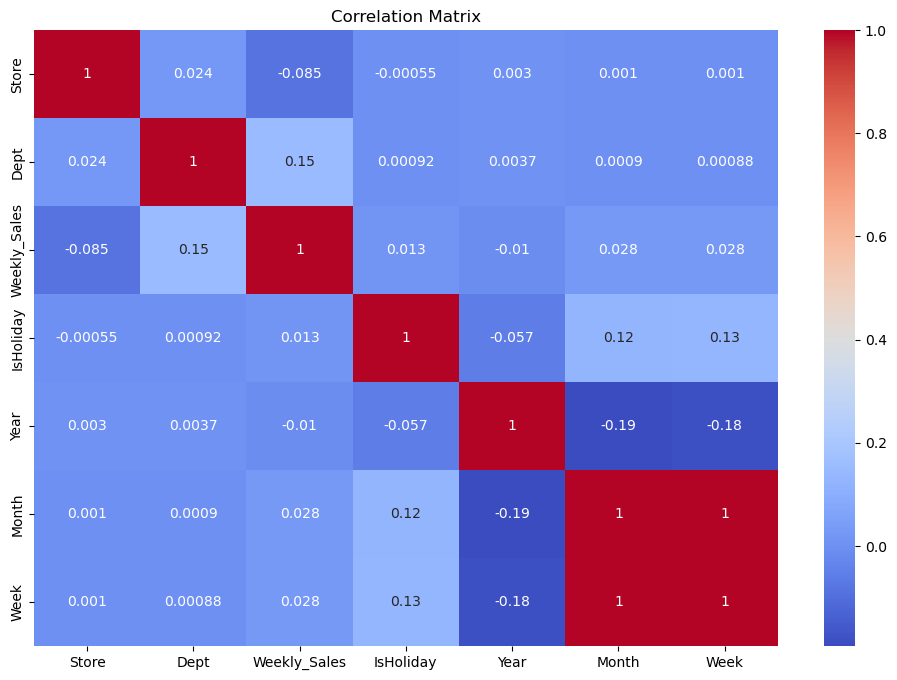

In [33]:
numeric_df = cleaned_data.select_dtypes(include="number")

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [34]:
cleaned_data["Week"].unique()

array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
       22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,
       39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,  1,  2,  3,
        4])

In [35]:
negative_df = data[data["Weekly_Sales"] < 0]

print(negative_df.describe())

             Store         Dept                           Date  Weekly_Sales
count  1285.000000  1285.000000                           1285   1285.000000
mean     23.858366    49.999222  2011-07-03 19:19:50.661478656    -68.608218
min       1.000000     5.000000            2010-02-05 00:00:00  -4988.940000
25%      15.000000    31.000000            2010-11-12 00:00:00    -41.000000
50%      22.000000    47.000000            2011-07-01 00:00:00    -13.200000
75%      35.000000    59.000000            2012-03-16 00:00:00     -4.940000
max      45.000000    99.000000            2012-10-26 00:00:00     -0.020000
std      12.033126    24.394330                            NaN    231.664245


In [36]:
print(negative_df.groupby("Dept").size().sort_values(ascending=False).head(10))

print(negative_df.groupby("Store").size().sort_values(ascending=False).head(10))

Dept
47    254
18    180
54    146
19     87
94     77
80     68
49     67
59     44
72     34
78     33
dtype: int64
Store
35    124
18     52
10     50
17     49
15     45
42     44
22     41
31     39
39     38
20     38
dtype: int64


In [37]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [38]:
cleaned_features= features.copy()
cleaned_features["IsHoliday"] = cleaned_features["IsHoliday"].astype(int)
cleaned_features["Date"] = pd.to_datetime(cleaned_features["Date"])

In [39]:
cleaned_features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,1
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,0
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,0
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,0


In [40]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [41]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [42]:
stores["Type"].unique()

array(['A', 'B', 'C'], dtype=object)

In [43]:
cleaned_stores= stores.copy()
cleaned_stores = pd.get_dummies(
    stores,
    columns=["Type"],
    dtype=int
)
cleaned_stores.head()

,Store,Size,Type_A,Type_B,Type_C
0,1,151315,1,0,0
1,2,202307,1,0,0
2,3,37392,0,1,0
3,4,205863,1,0,0
4,5,34875,0,1,0


In [44]:
df = cleaned_data.merge(
    cleaned_features,
    on=["Store", "Date", "IsHoliday"]
)

df = df.merge(
    cleaned_stores,
    on="Store"
)

In [45]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Temperature,Fuel_Price,...,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Type_A,Type_B,Type_C
0,1,1,2010-02-05,24924.50,0,2010,2,5,42.31,2.572,...,NaN,NaN,NaN,NaN,211.096358,8.106,151315,1,0,0
1,1,1,2010-02-12,46039.49,1,2010,2,6,38.51,2.548,...,NaN,NaN,NaN,NaN,211.242170,8.106,151315,1,0,0
2,1,1,2010-02-19,41595.55,0,2010,2,7,39.93,2.514,...,NaN,NaN,NaN,NaN,211.289143,8.106,151315,1,0,0
3,1,1,2010-02-26,19403.54,0,2010,2,8,46.63,2.561,...,NaN,NaN,NaN,NaN,211.319643,8.106,151315,1,0,0
4,1,1,2010-03-05,21827.90,0,2010,3,9,46.50,2.625,...,NaN,NaN,NaN,NaN,211.350143,8.106,151315,1,0,0


In [46]:
df.shape

(421570, 21)

In [47]:
df.isna().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Year                 0
Month                0
Week                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Size                 0
Type_A               0
Type_B               0
Type_C               0
dtype: int64

In [48]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

df[markdown_cols] = df[markdown_cols].fillna(0)

In [49]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Temperature,Fuel_Price,...,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Type_A,Type_B,Type_C
0,1,1,2010-02-05,24924.50,0,2010,2,5,42.31,2.572,...,0.0,0.0,0.0,0.0,211.096358,8.106,151315,1,0,0
1,1,1,2010-02-12,46039.49,1,2010,2,6,38.51,2.548,...,0.0,0.0,0.0,0.0,211.242170,8.106,151315,1,0,0
2,1,1,2010-02-19,41595.55,0,2010,2,7,39.93,2.514,...,0.0,0.0,0.0,0.0,211.289143,8.106,151315,1,0,0
3,1,1,2010-02-26,19403.54,0,2010,2,8,46.63,2.561,...,0.0,0.0,0.0,0.0,211.319643,8.106,151315,1,0,0
4,1,1,2010-03-05,21827.90,0,2010,3,9,46.50,2.625,...,0.0,0.0,0.0,0.0,211.350143,8.106,151315,1,0,0


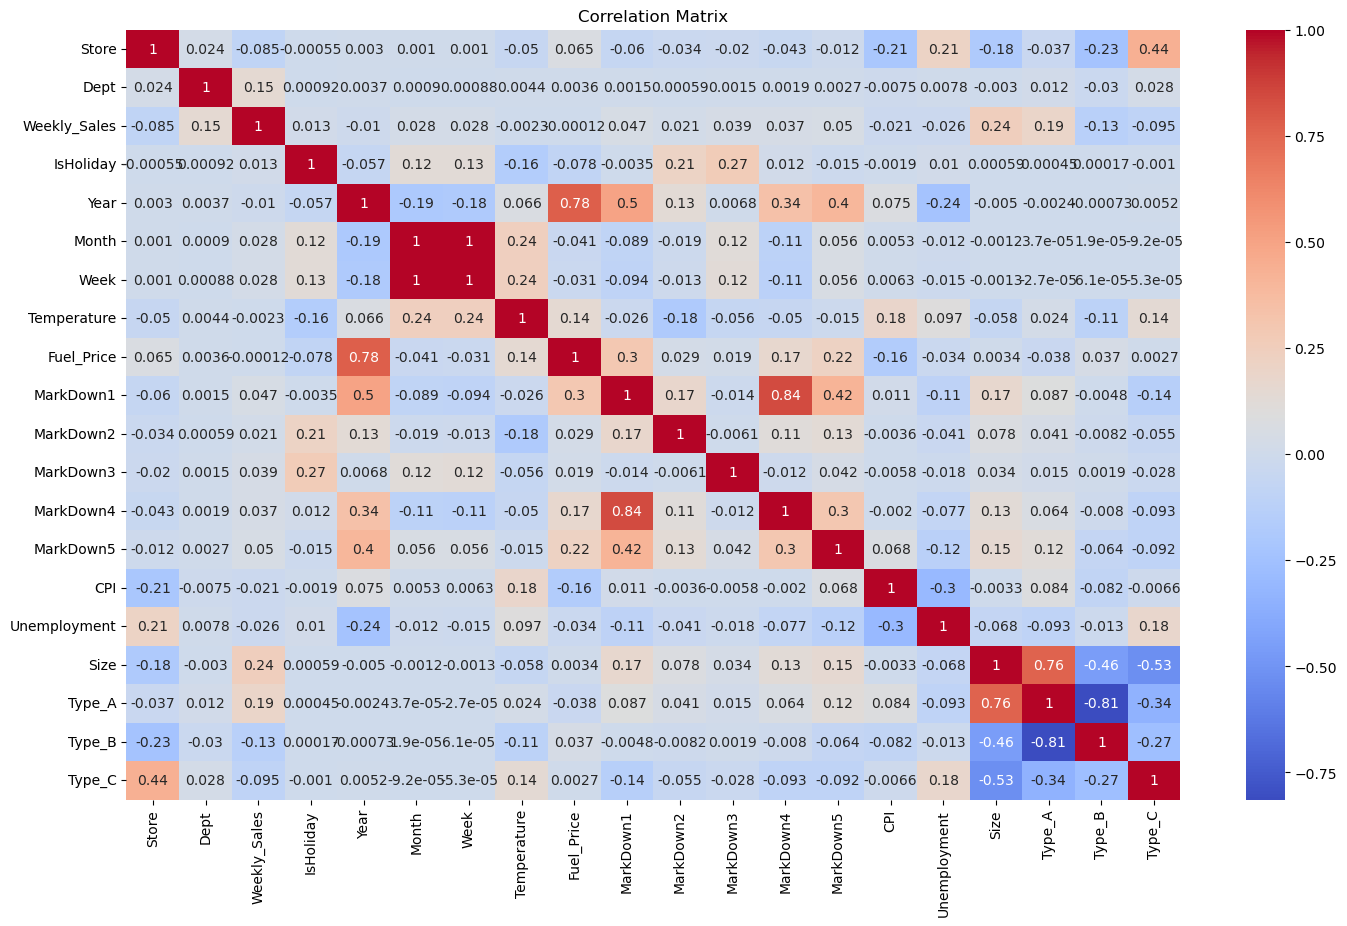

In [50]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(17,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [51]:
df.shape

(421570, 21)

# Feature Engineering 

In [52]:
from src.feature_engineering import create_lag_features

feature_df = create_lag_features(df)

feature_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Temperature,Fuel_Price,...,Unemployment,Size,Type_A,Type_B,Type_C,Lag_1,Lag_2,Lag_4,Lag_8,Lag_52
0,1,1,2010-02-05,24924.50,0,2010,2,5,42.31,2.572,...,8.106,151315,1,0,0,NaN,NaN,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,1,2010,2,6,38.51,2.548,...,8.106,151315,1,0,0,24924.50,NaN,NaN,NaN,NaN
2,1,1,2010-02-19,41595.55,0,2010,2,7,39.93,2.514,...,8.106,151315,1,0,0,46039.49,24924.50,NaN,NaN,NaN
3,1,1,2010-02-26,19403.54,0,2010,2,8,46.63,2.561,...,8.106,151315,1,0,0,41595.55,46039.49,NaN,NaN,NaN
4,1,1,2010-03-05,21827.90,0,2010,3,9,46.50,2.625,...,8.106,151315,1,0,0,19403.54,41595.55,24924.5,NaN,NaN


In [53]:
def create_advanced_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    df = df.sort_values(by=["Store", "Dept", "Date"])
    
    for window in [4, 12]:
        group = df.groupby(["Store", "Dept"])["Lag_1"]
        df[f"Sales_Roll_Mean_{window}"] = group.transform(lambda x: x.rolling(window=window, min_periods=1).mean())

        df[f"Sales_Roll_Std_{window}"] = group.transform(lambda x: x.rolling(window=window, min_periods=1).std()).fillna(0)
        
    for span in [4, 12]:
        df[f"Sales_EMA_{span}"] = (df.groupby(["Store", "Dept"])["Lag_1"].transform(lambda x: x.ewm(span=span, adjust=False).mean()))
        
    return df

advanced_df = create_advanced_features(feature_df)
advanced_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Temperature,Fuel_Price,...,Lag_2,Lag_4,Lag_8,Lag_52,Sales_Roll_Mean_4,Sales_Roll_Std_4,Sales_Roll_Mean_12,Sales_Roll_Std_12,Sales_EMA_4,Sales_EMA_12
0,1,1,2010-02-05,24924.50,0,2010,2,5,42.31,2.572,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN
1,1,1,2010-02-12,46039.49,1,2010,2,6,38.51,2.548,...,NaN,NaN,NaN,NaN,24924.500000,0.000000,24924.500000,0.000000,24924.50000,24924.500000
2,1,1,2010-02-19,41595.55,0,2010,2,7,39.93,2.514,...,24924.50,NaN,NaN,NaN,35481.995000,14930.552614,35481.995000,14930.552614,33370.49600,28172.960000
3,1,1,2010-02-26,19403.54,0,2010,2,8,46.63,2.561,...,46039.49,NaN,NaN,NaN,37519.846667,11131.900957,37519.846667,11131.900957,36660.51760,30237.973846
4,1,1,2010-03-05,21827.90,0,2010,3,9,46.50,2.625,...,41595.55,24924.5,NaN,NaN,32990.770000,12832.106391,32990.770000,12832.106391,29757.72656,28571.137870


In [54]:
advanced_df.isna().sum()

Store                      0
Dept                       0
Date                       0
Weekly_Sales               0
IsHoliday                  0
Year                       0
Month                      0
Week                       0
Temperature                0
Fuel_Price                 0
MarkDown1                  0
MarkDown2                  0
MarkDown3                  0
MarkDown4                  0
MarkDown5                  0
CPI                        0
Unemployment               0
Size                       0
Type_A                     0
Type_B                     0
Type_C                     0
Lag_1                   3331
Lag_2                   6625
Lag_4                  13134
Lag_8                  25966
Lag_52                160487
Sales_Roll_Mean_4       3331
Sales_Roll_Std_4           0
Sales_Roll_Mean_12      3331
Sales_Roll_Std_12          0
Sales_EMA_4             3331
Sales_EMA_12            3331
dtype: int64

In [55]:
processed_path = "../data/processed/processed_data.csv"

advanced_df.to_csv(processed_path, index=False)

print(f"Successfully saved cleaned dataset to: {processed_path}")

Successfully saved cleaned dataset to: ../data/processed/processed_data.csv
